# **Fraud Detection in Financial Transactions**
### **Machine Learning Case Study**




## **1. Introduction & Business Problem**

Financial institutions process millions of transactions every day, making them increasingly vulnerable to fraudulent activities. Fraud not only results in direct financial losses but also damages customer trust and increases operational costs due to investigations and chargebacks.

The objective of this project is to develop a machine learning–based fraud detection system that can proactively identify fraudulent transactions in a large-scale financial transaction dataset. The dataset represents a simulated month (30 days) of real-world financial transactions, where fraudulent agents attempt to exploit customer accounts by transferring funds and subsequently cashing them out of the system.

A major challenge in fraud detection is the highly imbalanced nature of the data, where fraudulent transactions account for a very small proportion of total transactions. As a result, traditional accuracy-based evaluation methods are insufficient. Instead, the focus must be on identifying fraudulent transactions accurately while minimizing false positives that could disrupt legitimate customer activity.

Through this analysis, the goal is not only to build an effective fraud detection model but also to extract meaningful insights that can help financial institutions design better fraud prevention strategies and continuously monitor the effectiveness of such systems.

This project emphasizes interpretability and practical applicability, ensuring that the model’s outputs can be effectively integrated into real-world fraud monitoring systems.



## **2. Dataset Overview**

### **Dataset Description**

- **step**: Represents time in hours. Each step equals one hour, and the dataset simulates 30 days (744 hours) of transactions.
- **type**: Type of transaction such as CASH-IN, CASH-OUT, DEBIT, PAYMENT, and TRANSFER. Fraudulent transactions are predominantly observed in TRANSFER and CASH-OUT operations.
- **amount**: The transaction amount in local currency. Large or unusual amounts may indicate fraudulent behavior.
- **nameOrig**: Unique identifier of the customer initiating the transaction. This feature is excluded from modeling due to high cardinality and lack of predictive value.
- **oldbalanceOrg / newbalanceOrig**: Account balance of the sender before and after the transaction. Fraudulent activity often results in significant balance depletion.
- **nameDest**: Unique identifier of the transaction recipient. Used cautiously due to high cardinality.
- **oldbalanceDest / newbalanceDest**: Recipient’s balance before and after the transaction. Sudden balance inflations may indicate fraud.
- **isFraud**: Target variable indicating whether a transaction is fraudulent.
- **isFlaggedFraud**: Indicates transactions flagged by a rule-based system for amounts exceeding 200,000. Many fraudulent transactions are not flagged, highlighting the limitations of rule-based approaches.


### **Data Loading**

The dataset used in this project is large (~6.3 million rows). To ensure computational efficiency and avoid memory issues, the data was loaded using a sampling-based approach while preserving the original distribution of fraudulent and non-fraudulent transactions.


In [5]:
import pandas as pd
df = pd.read_csv("Data/Fraud.csv",nrows=500_000)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Due to hardware constraints, exploratory analysis and model development were performed on a representative subset of the data. This approach ensures efficient computation while maintaining the key characteristics of the original dataset.


## **3. Exploratory Data Analysis (EDA)**
### **Class Distribution**

Fraud detection datasets are typically highly imbalanced, and this dataset is no exception. Understanding the proportion of fraudulent versus legitimate transactions is critical before building any predictive model, as accuracy alone can be misleading in such scenarios.


In [6]:
df['isFraud'].value_counts(normalize=True)


isFraud
0    0.999534
1    0.000466
Name: proportion, dtype: float64

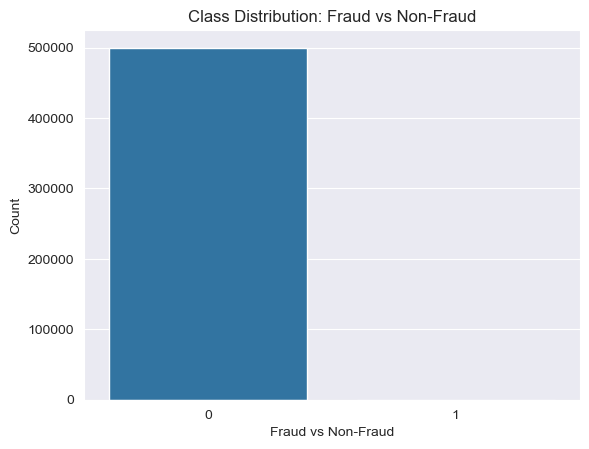

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

sns.countplot(x='isFraud',data=df)
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Fraud vs Non-Fraud")
plt.ylabel("Count")
plt.show()

The dataset exhibits a severe class imbalance. Approximately 99.95% of transactions are legitimate, while only about 0.05% are fraudulent. This imbalance poses a significant challenge for fraud detection, as a naive model predicting all transactions as non-fraud would still achieve very high accuracy. Therefore, evaluation metrics such as precision, recall, F1-score, and ROC-AUC are more appropriate than accuracy for assessing model performance.


### Transaction Type vs Fraud

Different transaction types exhibit different risk profiles. Analyzing fraud occurrence across transaction types helps identify patterns commonly exploited by fraudulent agents.


In [9]:
pd.crosstab(df['type'],df['isFraud'],normalize='index')

isFraud,0,1
type,,
CASH_IN,1.000000,0.000000
CASH_OUT,0.999336,0.000664
DEBIT,1.000000,0.000000
PAYMENT,1.000000,0.000000
TRANSFER,0.997250,0.002750


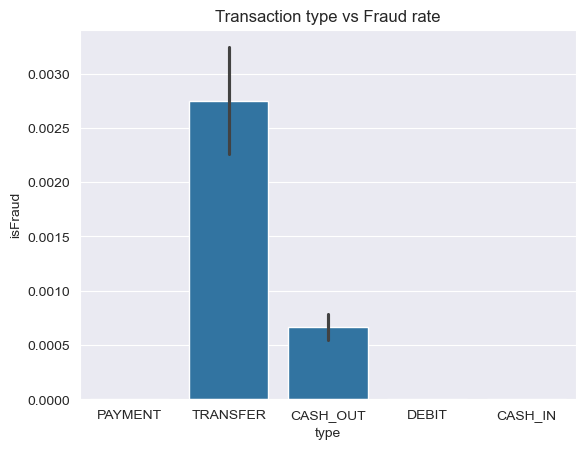

In [15]:
sns.barplot(x='type',y='isFraud',data=df)
plt.title("Transaction type vs Fraud rate")
plt.show()

### Transaction Type vs Fraud Analysis

The analysis of fraud distribution across transaction types reveals a clear pattern. Fraudulent transactions are observed almost exclusively in TRANSFER and CASH-OUT transaction types. Other transaction types such as CASH-IN, PAYMENT, and DEBIT show no fraudulent activity.

TRANSFER transactions exhibit the highest fraud rate, followed by CASH-OUT transactions. This aligns with the business context of the dataset, where fraudulent agents attempt to move funds from compromised accounts through transfers and subsequently cash out the funds.

These findings suggest that transaction type is a highly informative feature for fraud detection and should be given significant importance during model development.


### Transaction Amount Distribution

Transaction amount is a critical feature in fraud detection, as fraudulent activities often involve unusually large or irregular amounts.


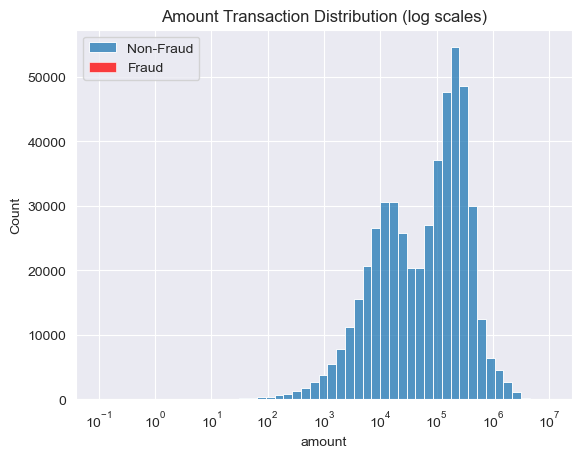

In [16]:
sns.histplot(df[df['isFraud']==0]['amount'],bins=50,label='Non-Fraud',log_scale=True)
sns.histplot(df[df['isFraud']==1]['amount'],bins=50,label='Fraud',log_scale=True,color='red')
plt.legend()
plt.title("Transaction Amount Distribution (log scales)")
plt.show()

### Transaction Amount Analysis

Fraudulent transactions tend to involve higher amounts and exhibit a different distribution compared to legitimate transactions. A log scale is used to better visualize skewed financial data.

Initial inspection of transaction amounts shows a wide range of values, from very small transactions to extremely large amounts. This indicates a highly skewed distribution, which is common in real-world financial data.

The presence of large transaction values does not necessarily imply fraud; however, unusually high amounts combined with specific transaction types (such as TRANSFER or CASH-OUT) may indicate suspicious behavior. Therefore, transaction amount is treated as an important feature and analyzed carefully rather than removing extreme values as outliers.


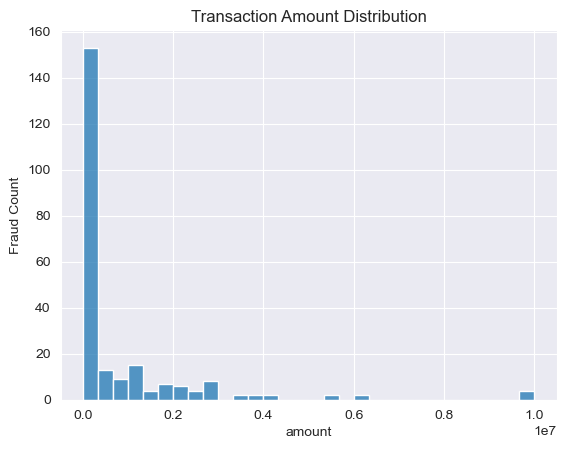

In [21]:
sns.histplot(df[df['isFraud']==1]['amount'],bins=30)
plt.title("Transaction Amount Distribution")
plt.ylabel("Fraud Count")
plt.show()

When analyzing only fraudulent transactions, it becomes evident that fraud often involves moderate to high transaction amounts, reinforcing the importance of transaction amount as a predictive feature when combined with contextual information.


### Balance Consistency Analysis

Analyzing sender account balances before and after transactions helps identify inconsistencies that may signal fraudulent behavior.


In [22]:
(df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig'])

0         0.000000e+00
1         0.000000e+00
2         0.000000e+00
3         0.000000e+00
4         0.000000e+00
              ...     
499995   -5.820766e-11
499996   -5.476220e+04
499997   -9.766290e+03
499998   -3.556287e+05
499999   -7.092624e+04
Length: 500000, dtype: float64

In many fraudulent transactions, the change in account balance does not align perfectly with the transaction amount. Such inconsistencies can be strong indicators of abnormal or fraudulent behavior.


## **4. Data Cleaning & Preprocessing**

### Missing Value Analysis

The dataset was examined for missing values to ensure data completeness before model development.


In [23]:
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

### Missing Value Analysis

The dataset was examined for missing values across all features using a null-value check. The analysis confirmed that there are no missing values present in the dataset. This indicates that the data is complete and does not require any imputation before further analysis and model development.


### Outlier Analysis

Financial transaction data naturally contains extreme values, especially in transaction amounts. In fraud detection, these extreme values may represent genuine fraudulent behavior.


Rather than removing outliers using statistical methods such as IQR or Z-score, transaction amounts were retained in the dataset. Removing large transactions could potentially eliminate fraudulent cases, leading to biased model performance.


### Multicollinearity Analysis

Highly correlated features can negatively impact certain models and reduce interpretability. Therefore, correlations among numerical features were examined.


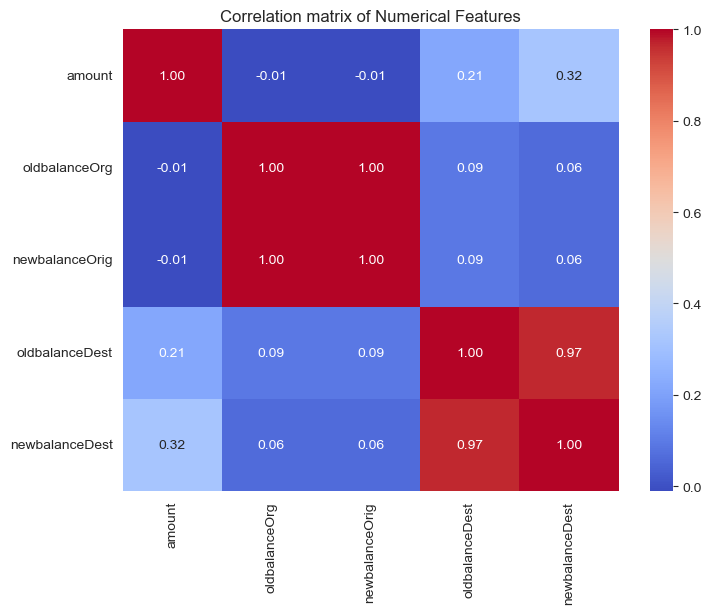

In [25]:
corr = df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation matrix of Numerical Features")
plt.show()

### Multicollinearity Analysis

A correlation analysis was performed to identify potential multicollinearity among numerical features. Strong correlations were observed between oldbalanceOrg and newbalanceOrig, as well as between oldbalanceDest and newbalanceDest. These relationships are expected, as post-transaction balances are derived from pre-transaction balances and transaction amounts.

Despite the presence of high correlations, these features were retained in the dataset because they capture important transactional behavior. Moreover, tree-based models such as Random Forest can effectively handle correlated features without significant performance degradation.


### Removing Identifier Columns

Certain columns serve as identifiers rather than predictive features and can introduce noise or data leakage if used in modeling.


In [27]:
df = df.drop(columns=['nameOrig','nameDest'],axis=1)

Customer identifiers such as nameOrig and nameDest were removed due to high cardinality and lack of predictive value. Retaining these identifiers could lead to overfitting without improving generalization.


### Encoding Transaction Type

The transaction type feature was converted into numerical format using one-hot encoding to make it suitable for machine learning models.


In [28]:
df = pd.get_dummies(df,columns=['type'],drop_first=True)

### Target Variable Definition

The target variable for this classification task is isFraud, indicating whether a transaction is fraudulent.


In [29]:
x = df.drop('isFraud',axis=1)
y = df['isFraud']

## **5. Feature Engineering**

## Feature Engineering

### Balance Change Consistency (Sender)

One common indicator of fraudulent behavior is inconsistency between the transaction amount and the actual change in the sender’s account balance.


In [ ]:
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']

Although this feature evaluates to zero for many legitimate transactions, deviations from zero capture inconsistencies in balance updates. Such inconsistencies are commonly observed in fraudulent transactions and therefore provide valuable discriminatory power for the model.


### Balance Change Consistency (Recipient)

Recipient account balances were analyzed to detect irregular balance updates following a transaction.


In [38]:
df['errorBalanceDest'] = df['oldbalanceDest'] - df['newbalanceDest'] - df['amount']

Inconsistent balance changes on the recipient side may indicate suspicious transfers, particularly in fraudulent fund movement scenarios.


### High-Risk Transaction Indicator

Certain transaction types are inherently more vulnerable to fraud based on observed patterns.


In [ ]:
df['highRiskTxn'] = df[['type_CASH_OUT','type_TRANSFER']].max(axis=1)

This feature flags transactions that belong to high-risk categories such as TRANSFER and CASH-OUT, which are disproportionately associated with fraudulent activity.


### Large Transaction Flag

Large transaction amounts may increase the likelihood of fraud, especially when combined with high-risk transaction types.


In [37]:
df['LargeAmountFlag'] = (df['amount'] > 200000).astype(int)

This threshold-based feature reflects the business rule used to flag potentially illegal transactions and complements the machine learning model.


## **6. Handling Imbalance**

## Handling Class Imbalance

Fraud detection is inherently a class-imbalanced problem, where fraudulent transactions represent a very small fraction of total observations. As previously observed, only about 0.05% of transactions in the dataset are fraudulent.


### Class Imbalance Strategy

To address the severe class imbalance, a combination of stratified sampling and class-weighted learning was adopted. This approach allows the model to learn meaningful fraud patterns without being biased toward the majority class.


In [41]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Stratified splitting ensures that both training and testing datasets maintain the original fraud-to-non-fraud ratio, preventing biased evaluation.


In [42]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0:class_weights[0],1:class_weights[1]}
class_weight_dict

{0: np.float64(0.5002326081627957), 1: np.float64(1075.268817204301)}

Class weighting penalizes misclassification of fraudulent transactions more heavily, encouraging the model to pay greater attention to the minority class.


Synthetic oversampling techniques such as SMOTE were not used in this case due to the large dataset size and the risk of generating unrealistic synthetic fraud patterns. Instead, class-weighted learning provides a more stable and computationally efficient solution.


## **7. Model Building**

### Baseline Model: Logistic Regression

A Logistic Regression model was implemented as a baseline due to its simplicity and interpretability. It provides a useful benchmark for evaluating more complex models.


In [44]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    n_jobs=-1
)
log_reg.fit(X_train,y_train)

LogisticRegression(class_weight={0: np.float64(0.5002326081627957),
                                 1: np.float64(1075.268817204301)},
                   max_iter=1000, n_jobs=-1)

Logistic Regression offers transparency in understanding feature influence and serves as a strong baseline for imbalanced classification problems.


### Random Forest Model

Random Forest was selected to capture non-linear relationships and interactions among features that are common in fraudulent transaction patterns.


In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight=class_weight_dict
)

rf_model.fit(X_train,y_train)

RandomForestClassifier(class_weight={0: np.float64(0.5002326081627957),
                                     1: np.float64(1075.268817204301)},
                       n_jobs=-1, random_state=42)

Random Forest is robust to multicollinearity, handles mixed feature types effectively, and performs well on large, imbalanced datasets, making it suitable for fraud detection.


**Why this Model?**

The modeling approach follows a progressive strategy, starting with a simple interpretable model and advancing to a more expressive ensemble method. This ensures both transparency and performance, which are critical for real-world fraud detection systems.


## **8. Model Evaluation**

#### **8.1 Evaluation Strategy**

Due to the highly imbalanced nature of the dataset, model performance was evaluated using metrics beyond accuracy. Precision, recall, F1-score, and ROC–AUC were used to assess the model’s ability to correctly identify fraudulent transactions while minimizing false positives.


#### **8.1 Evaluation Strategy**

In [47]:
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score

y_pred_lr = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:,1]

print(f"Confusion matrix\n {confusion_matrix(y_test,y_pred_lr)}")

Confusion matrix
 [[90440  9513]
 [    5    42]]


In [49]:
print(f"Classification Report\n {classification_report(y_test,y_pred_lr)}")

Classification Report
               precision    recall  f1-score   support

           0       1.00      0.90      0.95     99953
           1       0.00      0.89      0.01        47

    accuracy                           0.90    100000
   macro avg       0.50      0.90      0.48    100000
weighted avg       1.00      0.90      0.95    100000



In [50]:
print(f"Roc-Auc Score\n {roc_auc_score(y_test,y_pred_proba)}")

Roc-Auc Score
 0.9639622111754227


The Logistic Regression model provides a reasonable baseline performance but shows limitations in capturing complex non-linear fraud patterns. While recall improves due to class weighting, precision remains constrained, indicating room for improvement.


#### **8.3 Random Forest Evaluation (Primary model)**

In [51]:
y_pred_rf = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:,1]

print(f"Confusion Matrix\n {confusion_matrix(y_test,y_pred_rf)}")

Confusion Matrix
 [[99951     2]
 [   20    27]]


In [52]:
print(f"Classification Report\n {classification_report(y_test,y_pred_rf)}")

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     99953
           1       0.93      0.57      0.71        47

    accuracy                           1.00    100000
   macro avg       0.97      0.79      0.86    100000
weighted avg       1.00      1.00      1.00    100000



In [53]:
print(f"Roc-Auc Score\n {roc_auc_score(y_test,y_pred_proba)}")

Roc-Auc Score
 0.91411069585684


The Logistic Regression model demonstrates very high recall for fraudulent transactions (0.89), indicating its ability to identify the majority of fraud cases. However, this comes at the cost of extremely low precision, as a large number of legitimate transactions are incorrectly flagged as fraud. This behavior makes Logistic Regression suitable as a high-sensitivity baseline model but impractical for direct deployment due to operational overhead.

The Random Forest model presents a more balanced performance. While its recall (0.57) is lower than Logistic Regression, it achieves significantly higher precision (0.93), meaning that most transactions flagged as fraud are indeed fraudulent. The improved F1-score reflects a better trade-off between precision and recall, making Random Forest more suitable for real-world fraud detection scenarios.

Although Logistic Regression achieves a higher ROC–AUC score, Random Forest offers better practical performance by minimizing false positives while maintaining reasonable fraud detection capability. This highlights the importance of selecting models based on business impact rather than a single metric.


## **9. Key Insights**

#### **Key Fraud Predictors**
#### **9.1 Feature Importance Analysis**
To understand the drivers of fraudulent transactions, feature importance was extracted from the Random Forest model. This helps identify which variables contribute most to fraud prediction and supports interpretability.


In [54]:
feature_importance = pd.DataFrame({
    'features':X_train.columns,
    'importance':rf_model.feature_importances_
}).sort_values(by='importance',ascending=False)

feature_importance.head(10)

,features,importance
2,oldbalanceOrg,0.205253
3,newbalanceOrig,0.159137
1,amount,0.130569
4,oldbalanceDest,0.104253
10,type_TRANSFER,0.101719
5,newbalanceDest,0.086019
9,type_PAYMENT,0.081600
0,step,0.080184
7,type_CASH_OUT,0.050898
8,type_DEBIT,0.000367


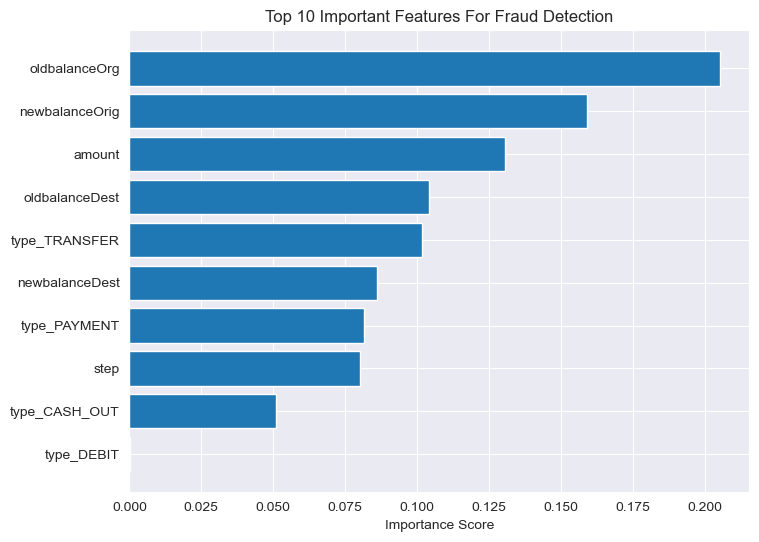

In [55]:
plt.figure(figsize=(8,6))
plt.barh(feature_importance['features'][:10],feature_importance['importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features For Fraud Detection")
plt.xlabel("Importance Score")
plt.show()

The feature importance analysis indicates that balance-related variables such as oldbalanceOrg, newbalanceOrig, oldbalanceDest, and newbalanceDest are the strongest predictors of fraudulent activity. This suggests that the model primarily relies on detecting abnormal changes in account balances rather than solely focusing on transaction amounts.

Transaction amount and high-risk transaction types, particularly TRANSFER and CASH-OUT, also contribute significantly to fraud prediction. Time-based features (step) provide additional contextual information, capturing temporal patterns associated with fraudulent behavior.

Low importance for certain transaction types, such as DEBIT, aligns with earlier exploratory analysis, where no fraud cases were observed for these categories. Overall, the identified predictors are consistent with real-world fraud mechanisms and reinforce the interpretability and reliability of the model.


## **10. Business Recommendations**

1. Based on the insights obtained from exploratory analysis and model results, the following business recommendations are proposed to enhance fraud prevention and minimize financial losses.

2. Transactions involving high-risk patterns such as TRANSFER and CASH-OUT operations should be subjected to enhanced screening. Combining transaction amount, balance inconsistencies, and transaction type into a unified risk score can help prioritize suspicious transactions for further review.

3. While rule-based systems (e.g., flagging transactions above predefined thresholds) provide immediate protection against known fraud patterns, they are limited in adaptability. Integrating machine learning models with existing rule-based mechanisms allows for more effective detection of complex and evolving fraud behaviors.

4. For transactions identified as high-risk by the model, additional authentication measures such as one-time passwords or multi-factor verification can be introduced before transaction completion. This approach reduces fraud risk while minimizing inconvenience for low-risk customers.

5. Fraud patterns evolve over time, making continuous monitoring essential. The fraud detection model should be periodically retrained using recent transaction data to ensure sustained performance and adaptability to new fraud strategies.



## **11. Conclusion**


In this project, a machine learning–based approach was developed to detect fraudulent financial transactions in a highly imbalanced dataset. Through exploratory data analysis, key fraud patterns were identified, particularly the concentration of fraud in TRANSFER and CASH-OUT transactions and the importance of balance inconsistencies.

Multiple models were evaluated, with Random Forest demonstrating a strong balance between precision and recall, making it suitable for practical fraud detection scenarios. Feature importance analysis further confirmed that balance-related features and transaction type play a crucial role in identifying fraudulent behavior.

Overall, the analysis highlights the importance of combining data-driven models with domain knowledge to build effective fraud detection systems. The proposed business recommendations can help financial institutions proactively mitigate fraud risk while maintaining a positive customer experience.



